In [1]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Final Project - Group 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

In [3]:
# # identify folder path
# folder_path = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data'

In [4]:
# # combine yearly datasets into one
# dfs = []

# for root, dirs, files in os.walk(folder_path):
#     for filename in files:
#         file_path = os.path.join(root, filename)
#         if filename.endswith(".xlsx"):
#             print(file_path)
#             df_raw = pd.read_excel(file_path)
#             df_raw['Source'] = filename
#             df_raw['Filepath'] = file_path

#             dfs.append(df_raw)

# df_all = pd.concat(dfs, ignore_index = True)

In [5]:
#df_all.info()

In [6]:
# export to excel
# output = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data\all_incidents_combined.xlsx'
# df_all.to_excel(output, index = False, freeze_panes = (1,0))

In [7]:
# reload the data
file = r"C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data\all_incidents_combined.xlsx"
df = pd.read_excel(file)

In [8]:
# examine data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  object        
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [9]:
# make dispatch_date_time a date format & convert from UTC to Eastern tz b/c Philly dataset
df['dispatch_date_time'] = pd.to_datetime(df['dispatch_date_time'], utc= True)

df['dispatch_date_time'] = df['dispatch_date_time'].dt.tz_convert("America/New_York")

df['dispatch_date_time'] = df['dispatch_date_time'].dt.tz_convert("America/New_York").dt.tz_localize(None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [10]:
# create month col
df['month'] = df['dispatch_date_time'].dt.month

# create day of week col
# 0 = Mon, 1 = Tues, 2 = Wed, 3 = Thurs, 4 = Fri, 5 = Sat, 6 = Sun       - - -    so 5 and 6 would be considered weekends
df['day_of_week'] = df['dispatch_date_time'].dt.dayofweek
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,600,Thefts,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,600,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,600,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,600,Thefts,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0


In [11]:
# create season col
df['season'] = df['month'].map({
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall", 
})
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,Thefts,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2,Winter
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,Thefts,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter


In [12]:
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,Thefts,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2,Winter
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,Thefts,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter


In [13]:
# create weekday/weekend col
df['week_type'] = df['day_of_week'].map({
    0: "Weekday", 1: "Weekday", 2: "Weekday", 3: "Weekday", 4: "Weekday",
    5: "Weekend", 6: "Weekend"
})
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_x,point_y,lat,lng,Source,Filepath,month,day_of_week,season,week_type
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer,Weekday
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer,Weekend
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring,Weekday
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter,Weekday
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2,Winter,Weekday
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter,Weekday


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [15]:
# look at stats
df.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481960.0,2326636.245857,1.0,160223.75,3287768.5,3408717.25,3529207.0,1475288.281407
objectid,481960.0,18196272.352347,96.0,8569044.75,17866839.0,28010682.25,38498485.0,10895389.405756
dc_dist,481960.0,17.454619,1.0,9.0,16.0,24.0,77.0,11.047697
dispatch_date_time,481960,2024-06-21 00:48:54.207473664,2022-12-31 19:05:00,2023-09-12 15:48:45,2024-06-17 16:58:30,2025-03-29 14:40:00,2025-12-31 18:58:00,NaN
dispatch_date,481960,2024-06-20 11:15:33.567931136,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381341.0,13.112464,0.0,9.0,13.0,17.0,23.0,5.68681
dc_key,481960.0,203253304431.106354,197935065350.0,202324002020.75,202415054325.5,202509022347.75,202503028015001.0,412015870727.543152
ucr_general,481960.0,974.754751,100.0,600.0,700.0,1100.0,2600.0,628.356818
point_x,464528.0,1889.869678,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.009472
point_y,464528.0,223.970884,0.0,39.958716,39.993153,40.03066,301244.661214,6833.493835


In [16]:
df.describe(include = 'object').T

,count,unique,top,freq
the_geom,464630,231560,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464513,231528,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_time,481960,2039,00:00:00,1132
location_block,481888,63365,5500 BLOCK TULIP ST,1769
text_general_code,481960,32,Thefts,114365
Source,481960,3,2023 incidents_use.xlsx,169017
Filepath,481960,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169017
season,481960,4,Summer,132304
week_type,481960,2,Weekday,362699


<Axes: ylabel='text_general_code'>

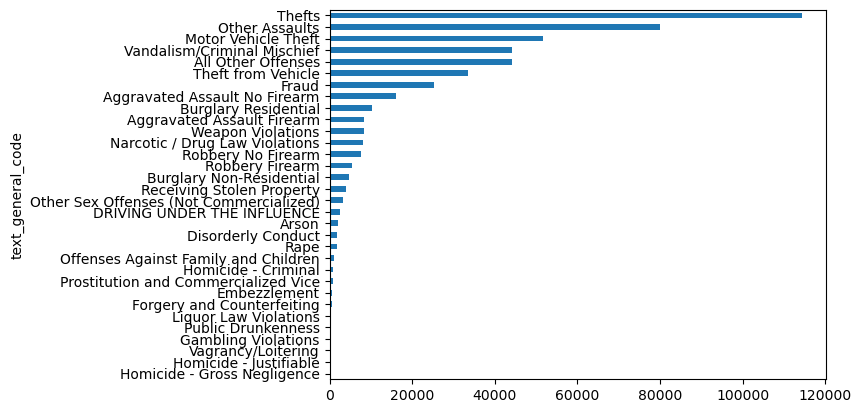

In [17]:
# look at crime type distribution
df['text_general_code'].value_counts().sort_values(ascending = True).plot(kind = 'barh')



array([[<Axes: title={'center': 'cartodb_id'}>,
        <Axes: title={'center': 'objectid'}>,
        <Axes: title={'center': 'dc_dist'}>,
        <Axes: title={'center': 'dispatch_date_time'}>],
       [<Axes: title={'center': 'dispatch_date'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'dc_key'}>,
        <Axes: title={'center': 'ucr_general'}>],
       [<Axes: title={'center': 'point_x'}>,
        <Axes: title={'center': 'point_y'}>,
        <Axes: title={'center': 'lat'}>, <Axes: title={'center': 'lng'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day_of_week'}>, <Axes: >, <Axes: >]],
      dtype=object)

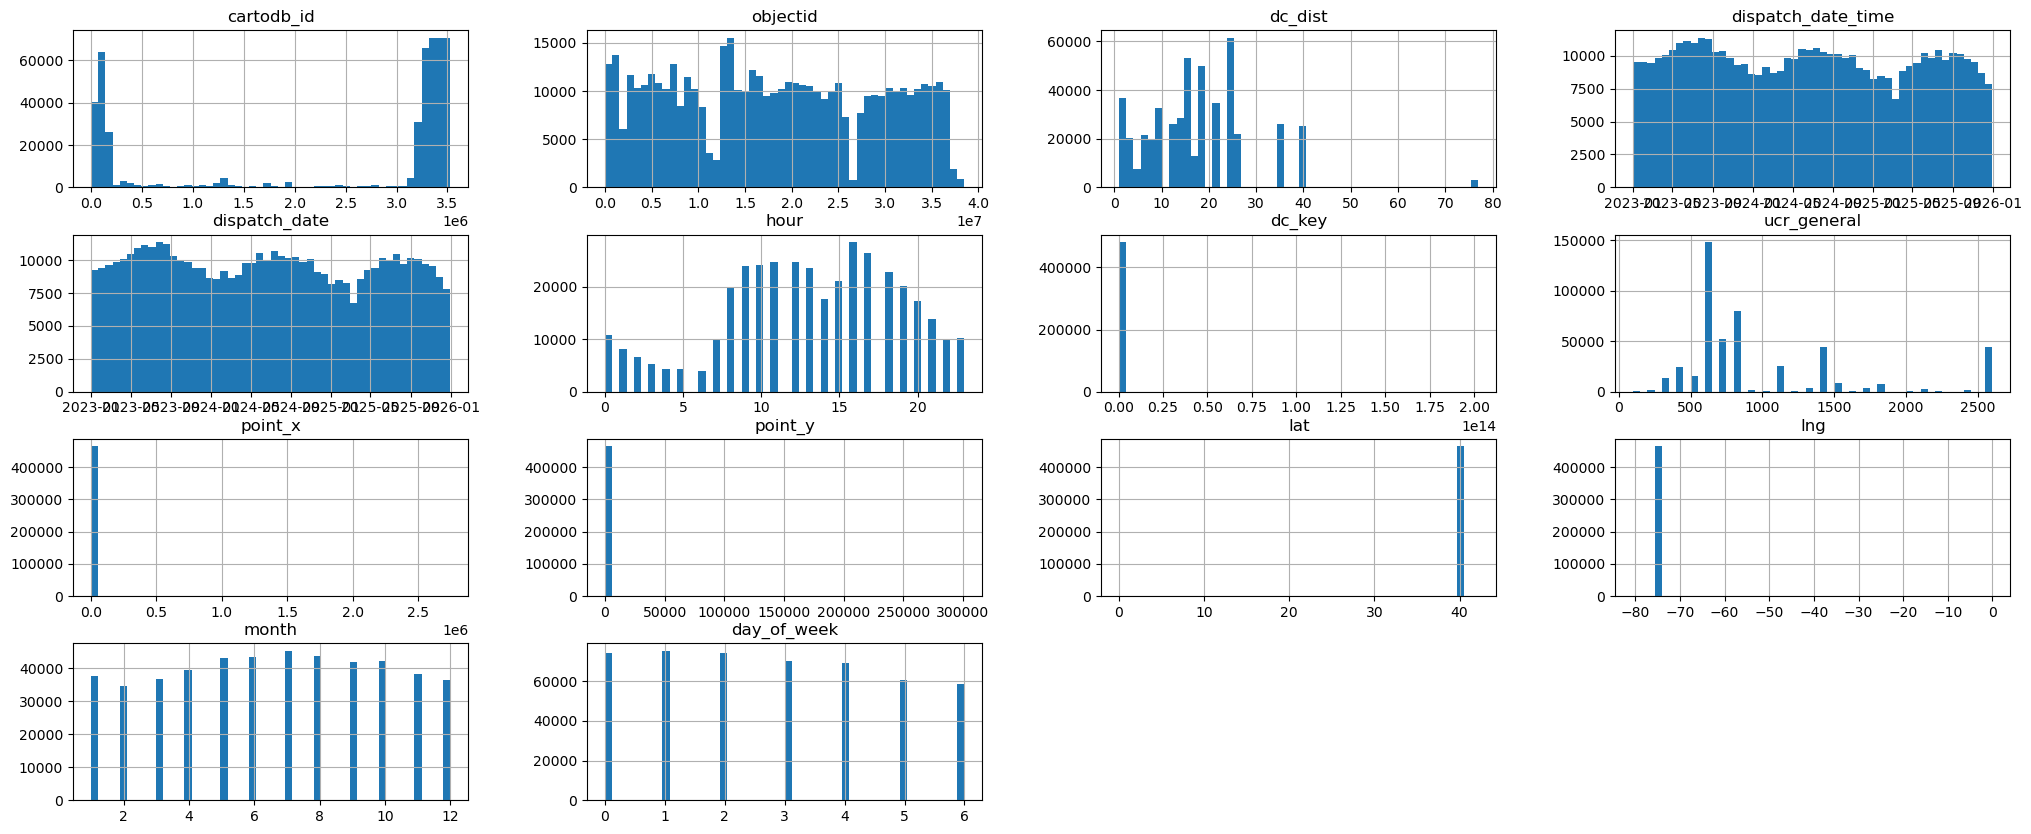

In [18]:
df.hist(bins = 50, figsize = (25, 10))

In [19]:
# classify crime types as violent or not and map text_general_codes
df['text_general_code'] = df['text_general_code'].str.lower().str.strip()


crime_mapping = {
    key.lower(): value for key, value in {
"Aggravated Assault Firearm":1,
"Aggravated Assault No Firearm":1,
"All Other Offenses":0,
"Arson":1,
"Burglary Non-Residential":1,
"Burglary Residential":1,
"Disorderly Conduct":0,
"DRIVING UNDER THE INFLUENCE":0,
"Embezzlement":0,
"Forgery and Counterfeiting":0,
"Fraud":0,
"Gambling Violations":0,
"Homicide - Criminal":1,
"Homicide - Gross Negligence":1,
"Homicide - Justifiable":1,
"Liquor Law Violations":0,
"Motor Vehicle Theft":0,
"Narcotic / Drug Law Violations":0,
"Offenses Against Family and Children":1,
"Other Assaults":1,
"Other Sex Offenses (Not Commercialized)":1,
"Prostitution and Commercialized Vice":0,
"Public Drunkenness":0,
"Rape":1,
"Receiving Stolen Property":0,
"Robbery Firearm":1,
"Robbery No Firearm":1,
"Theft from Vehicle":0,
"Thefts":0,
"Vagrancy/Loitering":0,
"Vandalism/Criminal Mischief":0,
"Weapon Violations":0,
}.items()}

df['violent_crime'] = df['text_general_code'].map(crime_mapping)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [21]:
''' notes to group:
I dont think we need hour if we're using date_time

Do we need point_x and point_y?? there are 17,400 missing values for point x and y not including incorrect numbers (0, etc.)

Do we need lat and long? there are 17,447 missing values

not sure if we need the_geom or the_geom_webmercator

do we need psa? It's "A single character field that names the Police Service Area boundary"

'''

# check for missing values
df.isnull().sum().sort_values(ascending = False)



hour                    100619
the_geom_webmercator     17447
lng                      17447
lat                      17447
point_y                  17432
point_x                  17432
the_geom                 17330
psa                        129
location_block              72
week_type                    0
season                       0
day_of_week                  0
month                        0
Filepath                     0
Source                       0
ucr_general                  0
text_general_code            0
cartodb_id                   0
dc_key                       0
dispatch_time                0
dispatch_date                0
dispatch_date_time           0
dc_dist                      0
objectid                     0
violent_crime                0
dtype: int64

In [22]:
# clean "location_block" 

'''do we impute these or delete them? idk if you really can impute them .... i think we should remove any rows where there are missing values esp b/c our dataset is so large.. thoughts?? '''

df['location_block'] = df['location_block'].str.lower().str.strip()

# if removing...
# df = df.dropna(subset = ["location_block"])
# df

In [23]:
#df.info()
df.columns

Index(['the_geom', 'cartodb_id', 'the_geom_webmercator', 'objectid', 'dc_dist',
       'psa', 'dispatch_date_time', 'dispatch_date', 'dispatch_time', 'hour',
       'dc_key', 'location_block', 'ucr_general', 'text_general_code',
       'point_x', 'point_y', 'lat', 'lng', 'Source', 'Filepath', 'month',
       'day_of_week', 'season', 'week_type', 'violent_crime'],
      dtype='object')

In [24]:
# remove any columns we dont need

''' 
thoughts about dropping the below columns ??? - should we also drop dc_dist and dc_key? it would give us 11 cols which is still OK per the project outline

DC_Dist	District	A two character field that names the District boundary.	Text
DC_Key	DC Number	The unique identifier of the crime that consists of Year + District + Unique ID.

'''

# cols_to_drop = ['the_geom', 'cartodb_id', 'the_geom_webmercator', 'dispatch_date', 'dispatch_time', 'hour', 'point_x', 'point_y', 'lat', 'lng', 'Source', 'Filepath']
# df = df.drop(columns = cols_to_drop)

' \nthoughts about dropping the below columns ??? - should we also drop dc_dist and dc_key? it would give us 11 cols which is still OK per the project outline\n\nDC_Dist\tDistrict\tA two character field that names the District boundary.\tText\nDC_Key\tDC Number\tThe unique identifier of the crime that consists of Year + District + Unique ID.\n\n'

In [25]:
cat_cols = df.select_dtypes(include = ['object']).columns
cat_cols

''' this part takes a while to run '''

# for col in cat_cols:
#     plt.figure(figsize = (4,4))

#     sns.countplot(data = df, x = col)

#     plt.show()


' this part takes a while to run '

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [31]:
# explore numerical columns
# num_cols = df.select_dtypes(include = [np.number]).columns
# corr_matrix = df[num_cols].corr()
# np.round(corr_matrix[''].sort_values(ascending = False), 4)

In [28]:
# sns.pairplot(df[num_cols])
# plt.show()

In [32]:
# # look at heatmap to see correlation between features 
# plt.figure(figsize=(12,8))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, mask=mask)
# plt.title('Correlation Matrix Heatmap')
# plt.show()

In [ ]:
# encode categorical cols

''' this is failing - I'm having memory issues because its trying to encode all cat cols which includes location which has a LOT of unique values... also i think its trying to encode the id col.. this may be a problem... thoughts?! '''

df = pd.get_dummies(df, columns = cat_cols, drop_first = True, dtype = int)

df.info()
df

MemoryError: Unable to allocate 416. GiB for an array with shape (481960, 231560) and data type int32

In [ ]:
# need to split data into training and testing - pass in your x matrix and the y value - then talk about how much data do you want to keep to test 
# (train model on diff dataset and predict on unseen data)

# drop target col and make y = target col

''' is target violent crime?? '''

X = df.drop('violent_crime', axis = 1)

y = df['violent_crime']

# split the data
# X_train = df w trainings features
# X_test = df w test features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y,)

In [ ]:
# scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # array
X_test_scaled = scaler.transform(X_test)         # array

In [ ]:
# create logistic regression model

lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

In [ ]:
#look at confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix for Logistic Regression')
plt.show()

# __ true negatives (predicted no _____ and actually no ______)
# __ false positives (predicted _____ but actually no _____)
# __ false negatives (predicted _____ but they actually had _____) **
# __ true positives (predicted _____ and actually had _____)

In [ ]:
# evaulate LR model - calc accuracy, precision, recall, f1
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
f1 = f1_score(y_test, y_pred)
print(f'Logistic Regression Model Performance:')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'F1-score: {f1:.4f}')